In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style(style = "darkgrid")

In [2]:
df = pd.read_csv(r"C:\Projects\Training\Week2\dataset\housing.csv")
print(df.head())
print("\nShape of the entire dataset.",df.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Shape of the entire dataset. (20640, 10)


1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [4]:
# categorical column
categorical_column = df["ocean_proximity"]
print(categorical_column.nunique())
print(categorical_column.unique())

5
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [7]:
# filling up the missing values with mean on total_bedrooms
# df["total_bedrooms"] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())
# df.isna().sum()

df.dropna(subset=["total_bedrooms"], inplace= True)
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [8]:
df = df.drop("ocean_proximity", axis = 1)
df.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
dtypes: float64(9)
memory usage: 1.6 MB


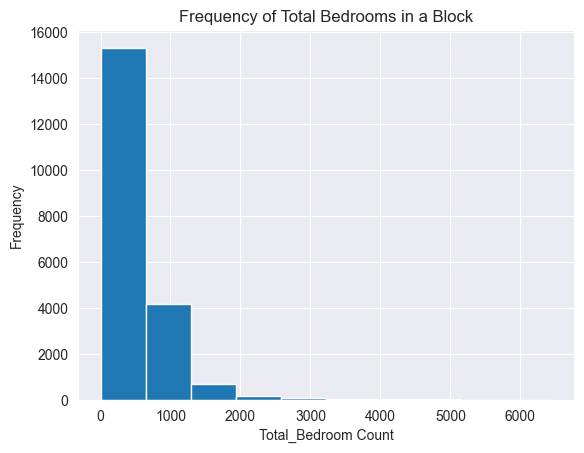

In [9]:
# plotting the values
plt.title(label = "Frequency of Total Bedrooms in a Block")
plt.hist(df["total_bedrooms"])
plt.xlabel("Total_Bedroom Count")
plt.ylabel("Frequency")
plt.show()

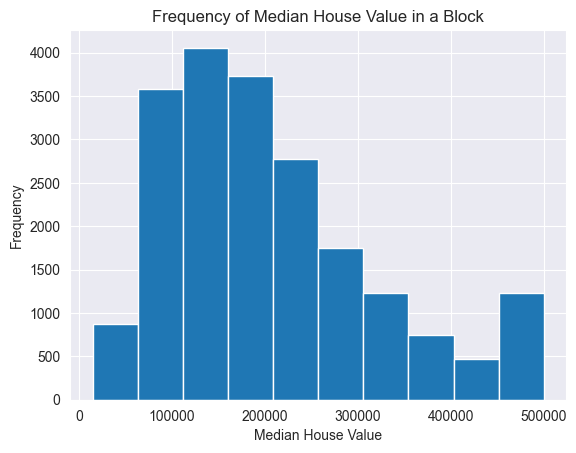

In [10]:
plt.title(label = "Frequency of Median House Value in a Block")
plt.hist(df["median_house_value"])
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

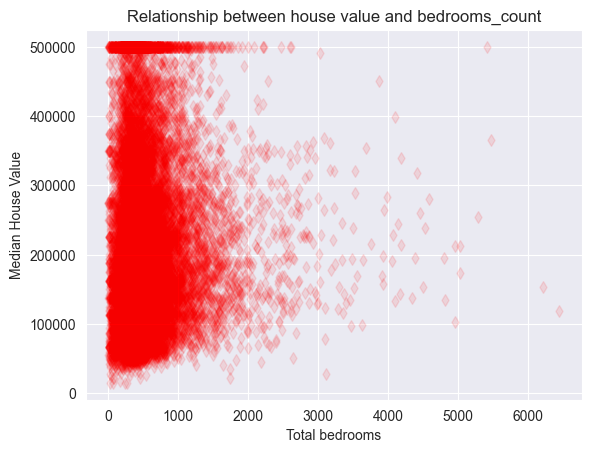

In [11]:
plt.title("Relationship between house value and bedrooms_count")
plt.scatter(df["total_bedrooms"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Total bedrooms")
plt.ylabel("Median House Value")
plt.show()

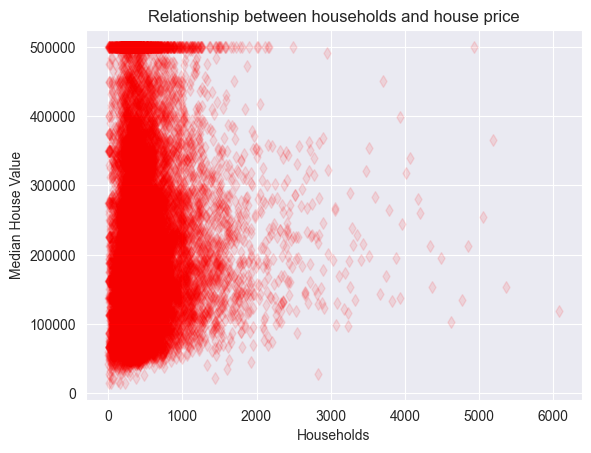

In [12]:
plt.title("Relationship between households and house price")
plt.scatter(df["households"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Households")
plt.ylabel("Median House Value")
plt.show()

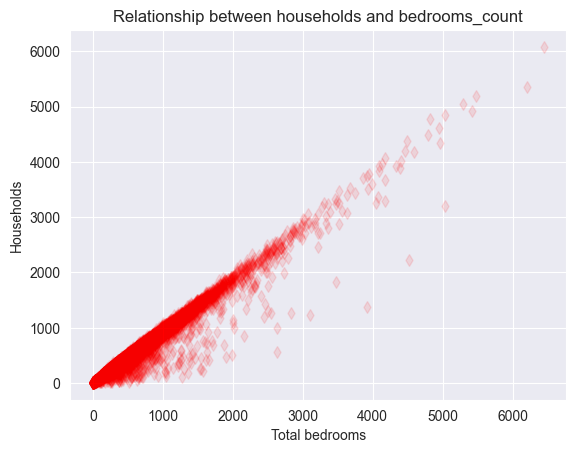

In [13]:
plt.title("Relationship between households and bedrooms_count")
plt.scatter(df["total_bedrooms"], y = df["households"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Total bedrooms")
plt.ylabel("Households")
plt.show()

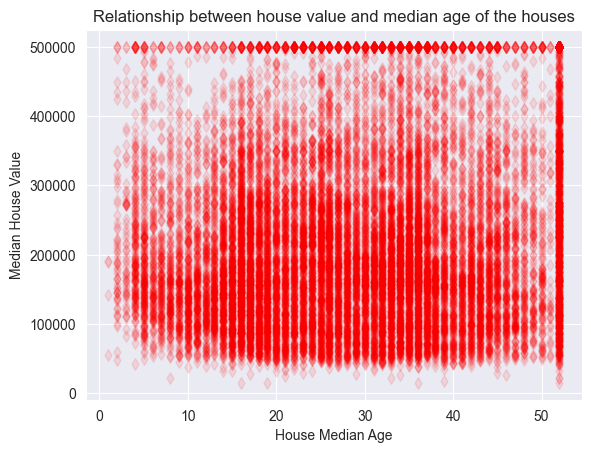

In [14]:
plt.title("Relationship between house value and median age of the houses")
plt.scatter(df["housing_median_age"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("House Median Age")
plt.ylabel("Median House Value")
plt.show()

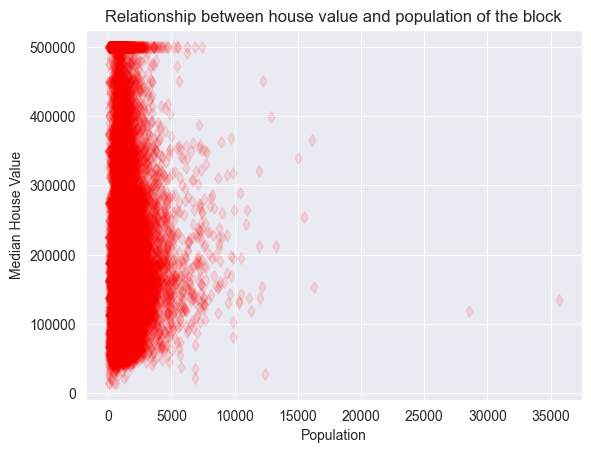

In [15]:
plt.title("Relationship between house value and population of the block")
plt.scatter(df["population"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Population")
plt.ylabel("Median House Value")
plt.show()

In [16]:
population = df["population"][df["median_house_value"] > 300000]
population.count()

np.int64(3800)

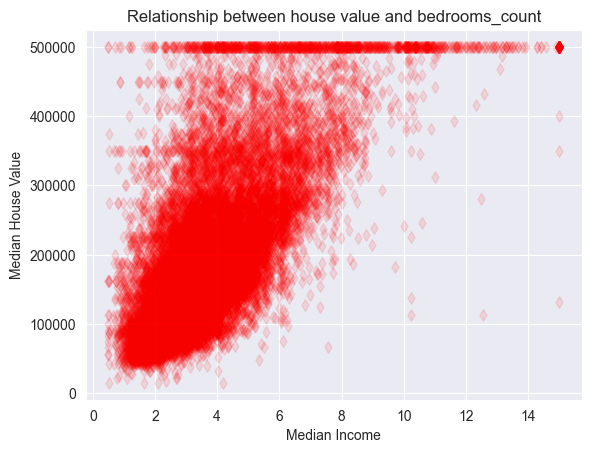

In [17]:
plt.title("Relationship between house value and bedrooms_count")
plt.scatter(df["median_income"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

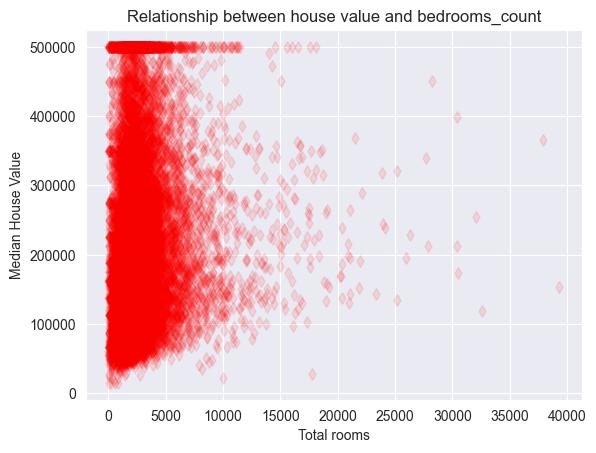

In [18]:
plt.title("Relationship between house value and bedrooms_count")
plt.scatter(df["total_rooms"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Total rooms")
plt.ylabel("Median House Value")
plt.show()

In [19]:
X = df.drop("median_house_value", axis = 1)
y = df.median_house_value

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("x_train", X_train.shape)
print("x_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

x_train (16346, 8)
x_test (4087, 8)
y_train (16346,)
y_test (4087,)


In [20]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)


In [21]:
print(X_train)

[[-1.2206e+02  3.7990e+01  1.7000e+01 ...  3.8400e+02  2.6900e+02
   1.8229e+00]
 [-1.1835e+02  3.4520e+01  1.4000e+01 ...  1.7100e+03  5.8000e+02
   5.9171e+00]
 [-1.2200e+02  3.8360e+01  3.4000e+01 ...  1.3900e+03  4.9100e+02
   2.7262e+00]
 ...
 [-1.1831e+02  3.3800e+01  3.1000e+01 ...  2.4200e+03  9.4700e+02
   4.0425e+00]
 [-1.2246e+02  3.7730e+01  5.2000e+01 ...  8.7600e+02  3.3800e+02
   7.8476e+00]
 [-1.1720e+02  3.2820e+01  3.5000e+01 ...  1.3920e+03  5.2100e+02
   3.3370e+00]]


In [35]:
# Z-score normalization
# (x - mean)/standard deviation

scaled_X_train = (X_train - np.mean(X_train, axis = 0)) / np.std(X_train, axis = 0)
scaled_X_test = (X_test - np.mean(X_test, axis = 0)) / np.std(X_test, axis = 0)
scaled_y_train = (y_train - np.mean(y_train, axis = 0)) / np.std(y_train, axis = 0)
scaled_y_test = (y_test - np.mean(y_test, axis = 0)) / np.std(y_test, axis = 0)
print(scaled_X_train.shape)
print(scaled_y_train.shape
      )

(16346, 8)
(16346, 1)


In [23]:
# Univariate Linear Regression

income_train = scaled_X_train[:, 7:8]
income_test = scaled_X_test[:, 7:8]
y_train_uni = scaled_y_train
y_test_uni = scaled_y_test

In [24]:
# Simple Linear Regression
# y_pred = wx + b  ------>  Here w is the weight, b is the bias and y_pred is the predicted value

# Linear model function
def model_function(x, w, b):
    y = w * x + b
    return y

# Cost function - Mean Squared Error
def cost_function(x, y, w, b):
    m = x.shape[0]  # Number of samples
    y_pred = model_function(x, w, b)
    cost = np.sum((y_pred - y) ** 2) / (2 * m)
    return cost

# Computing gradients using MSE
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    y_pred = model_function(x, w, b)
    error = y_pred - y
    
    gradient_w = np.sum(error * x) / m
    gradient_b = np.sum(error) / m
    return gradient_w, gradient_b

# Gradient descent with proper return
def gradient_descent(x, y, w, b, itr, alpha):
    cost_history = []
    for i in range(itr):
        gradient_w, gradient_b = compute_gradient(x, y, w, b)
        w = w - alpha * gradient_w
        b = b - alpha * gradient_b
        
        current_cost = cost_function(x, y, w, b)
        cost_history.append(current_cost)
        
        if i % 100 == 0:   # print every 100 iterations
            print(f"Iter {i}: Cost = {current_cost:.4f}")
    return w, b, cost_history

Iter 0: Cost = 75.8795


0.6885754857263471 0.00026561398887584074


C:\Users\HarshMaheshAgrawal\AppData\Local\Temp\ipykernel_5404\2048875647.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


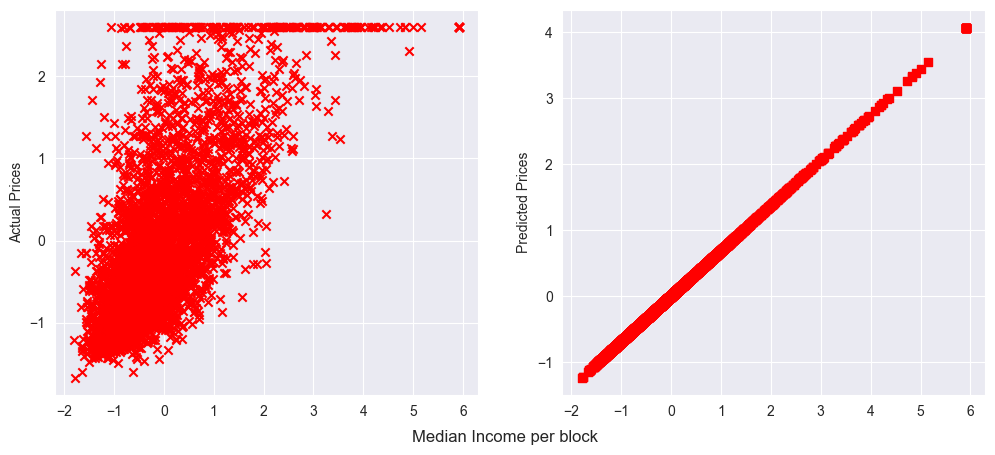

In [25]:
w, b, cost_history = gradient_descent(income_train, y_train_uni, 10,10, 100, 0.1)
y_pred_uni = model_function(income_test, w, b)

fig, axes = plt.subplots(1, 2, figsize = (12,5), sharex= True)
axes[0].scatter(income_test, y_test_uni, marker = "x", c = "r")
axes[0].set_ylabel("Actual Prices")
axes[1].scatter(income_test, y_pred_uni, marker = "s", c = "r")
axes[1].set_ylabel("Predicted Prices")
fig.supxlabel("Median Income per block")
fig.show()

print(w, b)

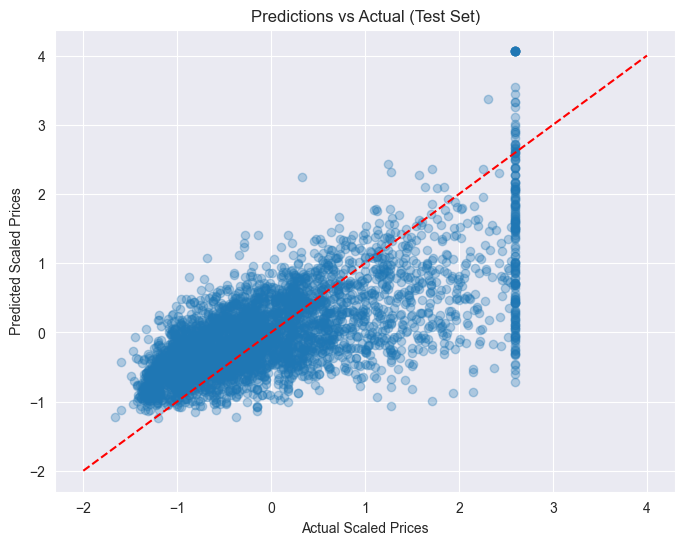

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(scaled_y_test, y_pred_uni, alpha=0.3)
plt.plot([-2, 4], [-2, 4], 'r--')   # ideal line
plt.xlabel('Actual Scaled Prices')
plt.ylabel('Predicted Scaled Prices')
plt.title('Predictions vs Actual (Test Set)')
plt.grid(True)
plt.show()

In [ ]:
# Multiple linear regression
# y_pred = (w_vector @ X) + b --> Here y_pred is again a vector with prediction of all the values

# 1. Add bias column (already suggested earlier)
# Since while doing multiple linear classification we consider bias as another wieght multiplied by 1.
X_train_b = np.c_[np.ones((scaled_X_train.shape[0], 1)), scaled_X_train]   # shape (16346, 9)
X_test_b  = np.c_[np.ones((scaled_X_test.shape[0], 1)), scaled_X_test]

# 2. Initialize weight
weight = np.zeros((X_train_b.shape[1], 1))   # shape (9, 1)
print(X_train_b)


In [ ]:

# 3. Vectorized Cost Function
def cost_function(X, y, weight):
    m = X.shape[0]
    y_pred = X @ weight
    cost = np.sum((y_pred - y) ** 2) / (2 * m)
    return cost

# 4. Vectorized Gradient
def compute_gradient(X, y, weight):
    m = X.shape[0]
    y_pred = X @ weight         # Prediction vector
    error = y_pred - y          # Error vector
    gradient = (1/m) * (X.T @ error)        # shape (9, 1)
    return gradient

# 5. Gradient Descent
def gradient_descent(X, y, weight, alpha, iterations):
    cost_history = []
    for i in range(iterations):
        gradient = compute_gradient(X, y, weight)
        weight = weight - alpha * gradient
        current_cost = cost_function(X, y, weight)
        cost_history.append(current_cost)
        
        if i % 200 == 0:
            print(f"Iter {i}: Cost = {current_cost:.4f}")
    return weight, cost_history

Iter 0: Cost = 0.4496
Iter 200: Cost = 0.1855
Iter 400: Cost = 0.1832
Iter 600: Cost = 0.1830
Iter 800: Cost = 0.1830
Iter 1000: Cost = 0.1830
Iter 1200: Cost = 0.1829
Iter 1400: Cost = 0.1829
Iter 1600: Cost = 0.1829
Iter 1800: Cost = 0.1829
(4087, 9) (4087, 1)


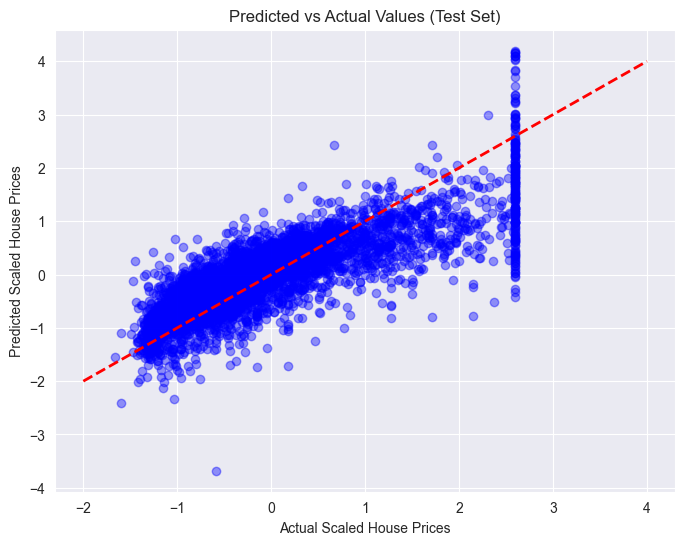

In [48]:
theta = np.zeros((X_train_b.shape[1], 1))   # (9, 1)

theta_final, cost_history = gradient_descent(X_train_b, scaled_y_train, theta, alpha=0.1, iterations=2000)
y_pred_scaled = X_test_b @ theta_final

print(X_test_b.shape, y_pred_scaled.shape)

plt.figure(figsize=(8, 6))
plt.scatter(scaled_y_test, y_pred_scaled, alpha=0.4, c='blue')
plt.plot([-2, 4], [-2, 4], 'r--', linewidth=2)   # ideal line where predicted = actual
plt.xlabel('Actual Scaled House Prices')
plt.ylabel('Predicted Scaled House Prices')
plt.title('Predicted vs Actual Values (Test Set)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures   # only for feature creation, not for modeling

# Create polynomial features (degree=2) on median_income
poly = PolynomialFeatures(degree=2, include_bias=False)

# Assuming median_income is column index 7 in scaled_X_train
income_train = scaled_X_train[:, 7:8]
income_test = scaled_X_test[:, 7:8]

income_poly_train = poly.fit_transform(income_train)
income_poly_test = poly.transform(income_test)

print("New shape after poly features:", income_poly_train.shape)
print("Old shape after poly features:", income_train.shape)
print(income_train[0:10, :])
print(income_poly_train[0:10, :])

New shape after poly features: (16346, 2)
Old shape after poly features: (16346, 1)
[[-1.07579796]
 [ 1.07521432]
 [-0.60122188]
 [ 0.84709417]
 [ 0.09580025]
 [-0.92869146]
 [ 2.45801543]
 [-0.43420346]
 [-0.64619444]
 [-0.15622471]]
[[-1.07579796  1.15734125]
 [ 1.07521432  1.15608583]
 [-0.60122188  0.36146775]
 [ 0.84709417  0.71756852]
 [ 0.09580025  0.00917769]
 [-0.92869146  0.86246782]
 [ 2.45801543  6.04183985]
 [-0.43420346  0.18853264]
 [-0.64619444  0.41756725]
 [-0.15622471  0.02440616]]


Iter 0: Cost = 0.4072
Iter 200: Cost = 0.2608
Iter 400: Cost = 0.2608
Iter 600: Cost = 0.2608
Iter 800: Cost = 0.2608


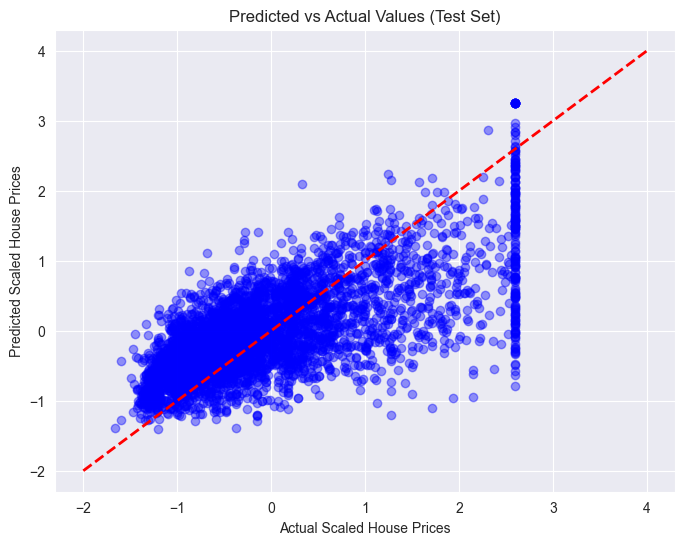

In [58]:
# 1. Use your existing polynomial data with bias
# (Assuming you already ran this)
X_train_poly_b = np.c_[np.ones((income_poly_train.shape[0], 1)), income_poly_train]
X_test_poly_b  = np.c_[np.ones((income_poly_test.shape[0], 1)), income_poly_test]

# 2. Initialize theta for 3 parameters
theta = np.zeros((X_train_poly_b.shape[1], 1))   # (3, 1)

# 3. Train using your EXISTING functions
theta_final, cost_history = gradient_descent(X_train_poly_b, scaled_y_train, theta, alpha=0.1, iterations=1000)

# 4. Predict on test
y_pred_scaled = X_test_poly_b @ theta_final

plt.figure(figsize=(8, 6))
plt.scatter(scaled_y_test, y_pred_scaled, alpha=0.4, c='blue')
plt.plot([-2, 4], [-2, 4], 'r--', linewidth=2)   # ideal line where predicted = actual
plt.xlabel('Actual Scaled House Prices')
plt.ylabel('Predicted Scaled House Prices')
plt.title('Predicted vs Actual Values (Test Set)')
plt.grid(True)
plt.show()

In [60]:
# Polynomial Regression for all the features.

# 1. Get polynomial features for income only (x and x²)
income_poly_train = poly.fit_transform(scaled_X_train[:, 7:8])   # assuming index 7 is median_income
income_poly_test  = poly.transform(scaled_X_test[:, 7:8])

# 2. Combine: original 8 features + income + income²
# Remove the original median_income to avoid duplication
original_without_income = np.delete(scaled_X_train, 7, axis=1)   # remove median_income column
X_train_final = np.hstack((original_without_income, income_poly_train))

original_without_income_test = np.delete(scaled_X_test, 7, axis=1)
X_test_final = np.hstack((original_without_income_test, income_poly_test))

# 3. Add bias column
X_train_final_b = np.c_[np.ones((X_train_final.shape[0], 1)), X_train_final]
X_test_final_b  = np.c_[np.ones((X_test_final.shape[0], 1)), X_test_final]

print("Final training shape (bias + features):", X_train_final_b.shape)

Final training shape (bias + features): (16346, 10)


Iter 0: Cost = 0.3918
Iter 200: Cost = 0.1823
Iter 400: Cost = 0.1817
Iter 600: Cost = 0.1816
Iter 800: Cost = 0.1816


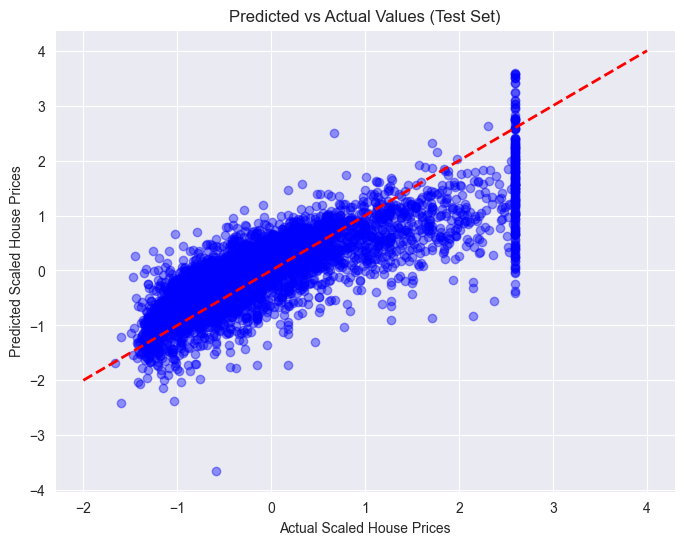

In [78]:
theta = np.zeros((X_train_final_b.shape[1], 1))
theta, cost_history = gradient_descent(X_train_final_b, scaled_y_train, theta, alpha = 0.15, iterations= 1000)
Y = X_test_final_b@ theta

plt.figure(figsize=(8, 6))
plt.scatter(scaled_y_test, Y, alpha=0.4, c='blue')
plt.plot([-2, 4], [-2, 4], 'r--', linewidth=2)   # ideal line where predicted = actual
plt.xlabel('Actual Scaled House Prices')
plt.ylabel('Predicted Scaled House Prices')
plt.title('Predicted vs Actual Values (Test Set)')
plt.grid(True)
plt.show()

Iter 0: Cost = 0.4379
Iter 200: Cost = 0.1919
Iter 400: Cost = 0.1841
Iter 600: Cost = 0.1824
Iter 800: Cost = 0.1820
Iter 1000: Cost = 0.1818
Iter 1200: Cost = 0.1817
Iter 1400: Cost = 0.1817
Iter 1600: Cost = 0.1817
Iter 1800: Cost = 0.1816


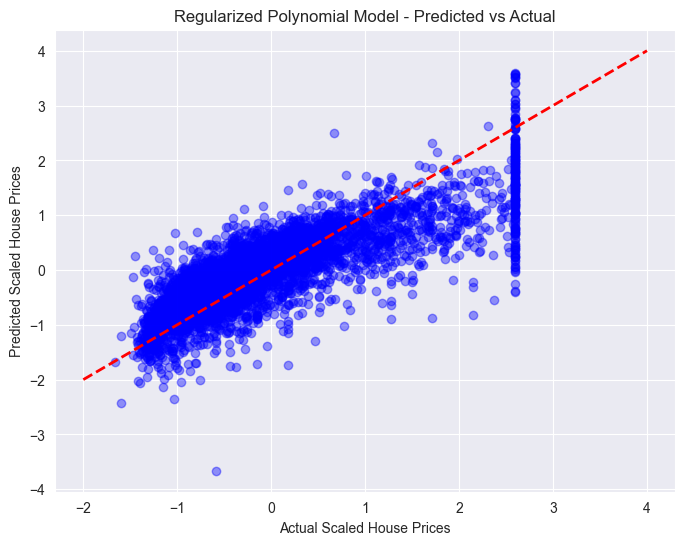

In [79]:
# L2 Regularization
# adding the regularization term

def cost_function(X, y, theta, lambda_reg=1.0):
    m = X.shape[0]
    y_pred = X @ theta
    mse = np.sum((y_pred - y) ** 2) / (2 * m)
    
    # L2 Regularization term (do NOT regularize the bias term theta[0])
    reg_term = (lambda_reg / (2 * m)) * np.sum(theta[1:] ** 2)
    
    return mse + reg_term

def compute_gradient(X, y, theta, lambda_reg=1.0):
    m = X.shape[0]
    y_pred = X @ theta
    error = y_pred - y
    
    gradient = (1 / m) * (X.T @ error)
    
    # Add regularization to all weights except bias (theta[0])
    gradient[1:] = gradient[1:] + (lambda_reg / m) * theta[1:]
    
    return gradient

def gradient_descent(X, y, theta, alpha, iterations, lambda_reg=1.0):
    cost_history = []
    for i in range(iterations):
        gradient = compute_gradient(X, y, theta, lambda_reg)
        theta = theta - alpha * gradient
        
        current_cost = cost_function(X, y, theta, lambda_reg)
        cost_history.append(current_cost)
        
        if i % 200 == 0:
            print(f"Iter {i}: Cost = {current_cost:.4f}")
    return theta, cost_history

# Initialize theta
theta = np.zeros((X_train_final_b.shape[1], 1))

# Train with regularization
lambda_reg = 1.0     # You can try 0.1, 1.0, 10.0 later
theta_final, cost_history = gradient_descent(X_train_final_b, scaled_y_train, 
                                             theta, alpha=0.05, iterations=2000, lambda_reg=lambda_reg)

# Predict
y_pred_scaled = X_test_final_b @ theta_final

plt.figure(figsize=(8, 6))
plt.scatter(scaled_y_test, y_pred_scaled, alpha=0.4, c='blue')
plt.plot([-2, 4], [-2, 4], 'r--', linewidth=2)
plt.xlabel('Actual Scaled House Prices')
plt.ylabel('Predicted Scaled House Prices')
plt.title('Regularized Polynomial Model - Predicted vs Actual')
plt.grid(True)
plt.show()